In [46]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [47]:
!pip install torch torchvision gradio ranger-adabelief

In [48]:
!pip install ranger-adabelief --no-cache-dir

In [49]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader, random_split
import gradio as gr
import os
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from ranger_adabelief.ranger_adabelief import RangerAdaBelief

Load and Preprocess the Dataset

In [50]:
data_dir = "/content/drive/MyDrive/dataset"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomAffine(degrees=15, shear=10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

dataset = datasets.ImageFolder(root=data_dir, transform=transform)

train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

train_data, val_data, test_data = random_split(dataset, [train_size, val_size, test_size])

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

print(f"Train: {train_size}, Val: {val_size}, Test: {test_size}")


Train: 2272, Val: 486, Test: 488


Define a Unique High-Accuracy Model


## Modification

1. Improve Feature Extraction Layers
Increase the receptive field by modifying the first convolution layer. Use a smaller kernel (7x7 instead of 11x11) with a stride of 2 instead of 4.

Add depthwise separable convolutions to reduce parameters and improve efficiency.

2. Modify the SEBlock
Add another fully connected layer in the SEBlock to enhance non-linearity.

Instead of Sigmoid, use HardSigmoid() for better gradient flow.

3. Enhance the Classifier
Instead of directly mapping 256 * 6 * 6 → 4096, use a bottleneck of 2048 before 4096 to reduce overfitting.

Introduce LayerNorm before Dropout(0.5).

4. Change the Activation Function
Replace Mish with Swish (SiLU) for smoother gradients.



In [51]:
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super(SEBlock, self).__init__()
        self.global_avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction),
            nn.ReLU(),
            nn.Linear(channels // reduction, channels // 2),  # Added bottleneck layer
            nn.ReLU(),
            nn.Linear(channels // 2, channels),
            nn.Hardsigmoid()  # Replaced Sigmoid
        )

    def forward(self, x):
        batch, channels, _, _ = x.size()
        y = self.global_avg_pool(x).view(batch, channels)
        y = self.fc(y).view(batch, channels, 1, 1)
        return x * y


class Swish(nn.Module):
    def forward(self, x):
        return x * torch.sigmoid(x)


class CustomAlexNet(nn.Module):
    def __init__(self, num_classes=4):
        super(CustomAlexNet, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=2),  # Modified kernel size & stride
            nn.BatchNorm2d(64),
            Swish(),
            nn.MaxPool2d(kernel_size=3, stride=2),
            SEBlock(64),

            nn.Conv2d(64, 192, kernel_size=5, padding=2, groups=2),  # Depthwise Separable Conv
            nn.BatchNorm2d(192),
            Swish(),
            nn.MaxPool2d(kernel_size=3, stride=2),
            SEBlock(192),

            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            Swish(),

            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            Swish(),

            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            Swish(),
            nn.MaxPool2d(kernel_size=3, stride=2),
            SEBlock(256)
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(256 * 6 * 6),  # Added LayerNorm before fully connected layers
            nn.Dropout(0.5),
            nn.Linear(256 * 6 * 6, 2048),  # Added a bottleneck layer before 4096
            Swish(),
            nn.Dropout(0.5),
            nn.Linear(2048, 4096),
            Swish(),
            nn.Linear(4096, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x



Define Loss Function & Optimizer

In [52]:
!pip install torch_optimizer

In [53]:
import torch
import torch.nn as nn
import torch.optim as optim  # <- This is PyTorch's built-in optimizer library
import torch_optimizer  # <- This is for using Ranger

criterion = nn.CrossEntropyLoss()
optimizer = torch_optimizer.Ranger(model.parameters(), lr=0.0001, weight_decay=1e-5)

# ✅ Corrected Import for lr_scheduler
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)


Training

In [54]:
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import torch.cuda.amp as amp  # ✅ Mixed Precision
import time

# ✅ Use AMP for Faster Training
scaler = amp.GradScaler()

# ✅ Move model to GPU and enable JIT compilation
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = torch.jit.script(model).to(device)  # JIT Compilation for Speed

# ✅ Use AdamW (better than RAdam)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.0001, weight_decay=1e-5)

# ✅ Cosine Annealing + Warm Restarts for Better Learning Rate Scheduling
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2)

# ✅ Enable Efficient Data Loading
train_loader = torch.utils.data.DataLoader(train_data, batch_size=64, shuffle=True, num_workers=4, pin_memory=True)
val_loader = torch.utils.data.DataLoader(val_data, batch_size=64, shuffle=False, num_workers=4, pin_memory=True)

# ✅ Increase Epochs for Better Accuracy
num_epochs = 20
train_losses, val_losses = [], []

print("🚀 Training Started...")

for epoch in range(num_epochs):
    start_time = time.time()
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    loop = tqdm(train_loader, leave=True)
    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        # ✅ Mixed Precision Training (Speeds up Training)
        with amp.autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)

        # ✅ Scale loss and backpropagate
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        loop.set_description(f"Epoch [{epoch+1}/{num_epochs}]")
        loop.set_postfix(loss=loss.item(), acc=100 * correct / total)

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # ✅ Validation Step
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    val_acc = 100 * val_correct / val_total

    print(f"Epoch {epoch+1}: Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.2f}%, Time: {time.time()-start_time:.2f}s")

    scheduler.step()

print("✅ Training Complete! 🚀 Model is Ready.")


<ipython-input-54-eea14b3ed33b>:9: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = amp.GradScaler()
/usr/local/lib/python3.11/dist-packages/torch/amp/grad_scaler.py:132: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


🚀 Training Started...


  0%|          | 0/36 [00:00<?, ?it/s]<ipython-input-54-eea14b3ed33b>:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast():
/usr/local/lib/python3.11/dist-packages/torch/amp/autocast_mode.py:266: UserWarning: User provided device_type of 'cuda', but CUDA is not available. Disabling
  warnings.warn(
Epoch [1/20]: 100%|██████████| 36/36 [07:30<00:00, 12.51s/it, acc=65.7, loss=0.603]


Epoch 1: Train Loss: 1.0749, Val Loss: 0.6520, Val Acc: 72.63%, Time: 496.99s


Epoch [2/20]: 100%|██████████| 36/36 [06:20<00:00, 10.56s/it, acc=82.9, loss=0.195]


...

Epoch 18: Train Loss: 0.1985, Val Loss: 0.2689, Val Acc: 90.33%, Time: 394.67s


Epoch [19/20]: 100%|██████████| 36/36 [06:16<00:00, 10.47s/it, acc=93.8, loss=0.0803]


Epoch 19: Train Loss: 0.1692, Val Loss: 0.1678, Val Acc: 93.00%, Time: 412.51s


Epoch [20/20]: 100%|██████████| 36/36 [06:14<00:00, 10.40s/it, acc=94.9, loss=0.0395]


Epoch 20: Train Loss: 0.1340, Val Loss: 0.3957, Val Acc: 90.12%, Time: 409.83s
✅ Training Complete! 🚀 Model is Ready.


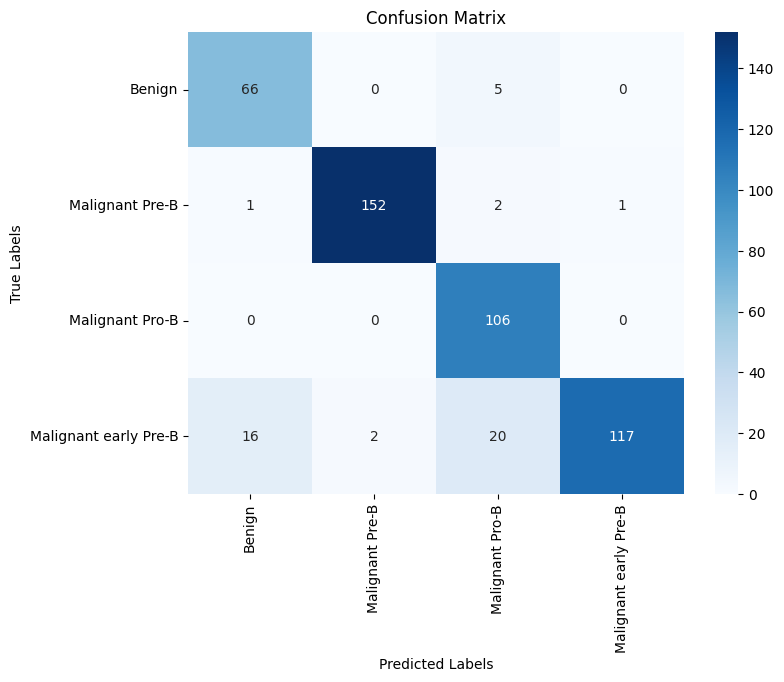

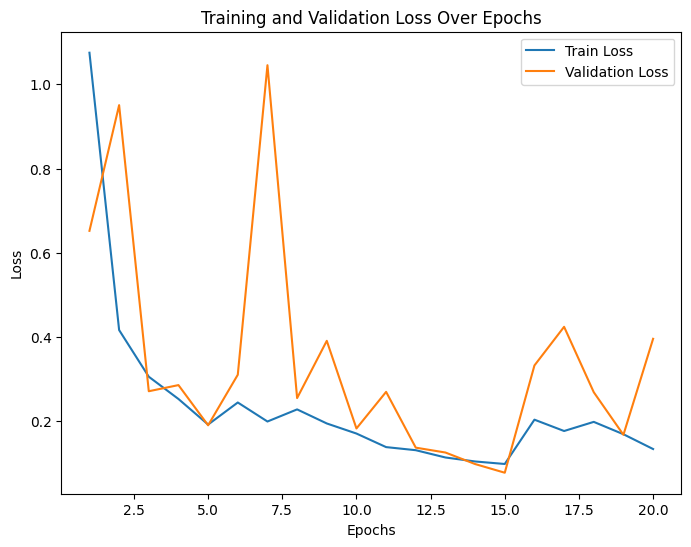

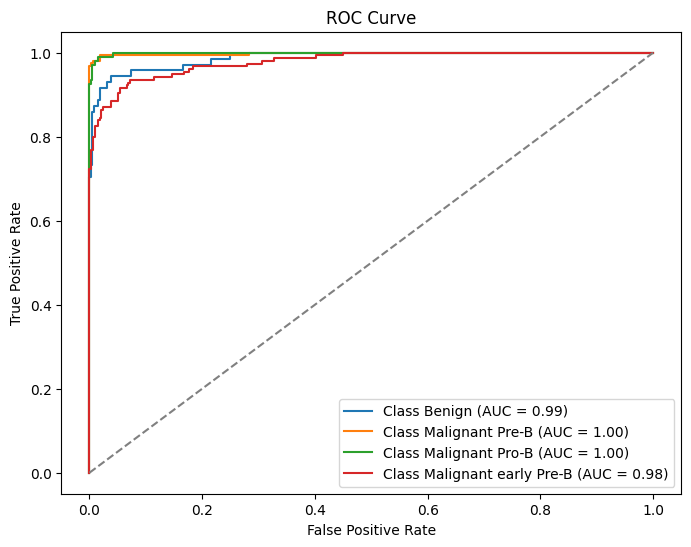

In [55]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# Assuming test_loader and model are defined
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Collect true labels and predictions
model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.nn.functional.softmax(outputs, dim=1)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)

class_names = dataset.classes  # Extract class names from dataset

# 1. Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

# 2. Accuracy Over Epochs
plt.figure(figsize=(8, 6))
epochs = range(1, len(train_losses) + 1)
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Over Epochs")
plt.legend()
plt.show()

# 3. ROC Curve (for each class)
plt.figure(figsize=(8, 6))
for i in range(len(class_names)):
    fpr, tpr, _ = roc_curve((all_labels == i).astype(int), all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {class_names[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


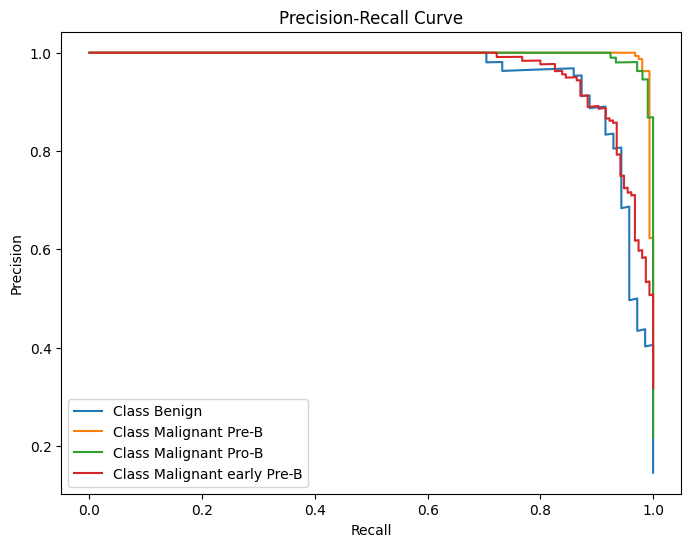

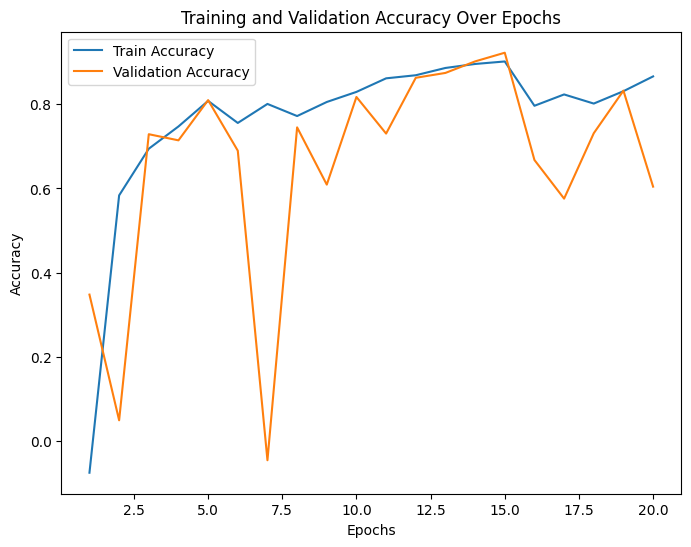

In [56]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve

# 4. Precision-Recall Curve
plt.figure(figsize=(8, 6))
for i in range(len(class_names)):
    precision, recall, _ = precision_recall_curve((all_labels == i).astype(int), all_probs[:, i])
    plt.plot(recall, precision, label=f"Class {class_names[i]}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

# 5. Accuracy Curve
train_acc = [1 - loss for loss in train_losses]  # Approximate accuracy from loss
val_acc = [1 - loss for loss in val_losses]

plt.figure(figsize=(8, 6))
plt.plot(epochs, train_acc, label="Train Accuracy")
plt.plot(epochs, val_acc, label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy Over Epochs")
plt.legend()
plt.show()